In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import warnings

warnings.filterwarnings("ignore")

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, classification_report

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3615s 21us/step


In [3]:
print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)
print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)

Training Images: (50000, 32, 32, 3)
Training Labels: (50000, 1)
Testing Images: (10000, 32, 32, 3)
Testing Labels: (10000, 1)


In [4]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

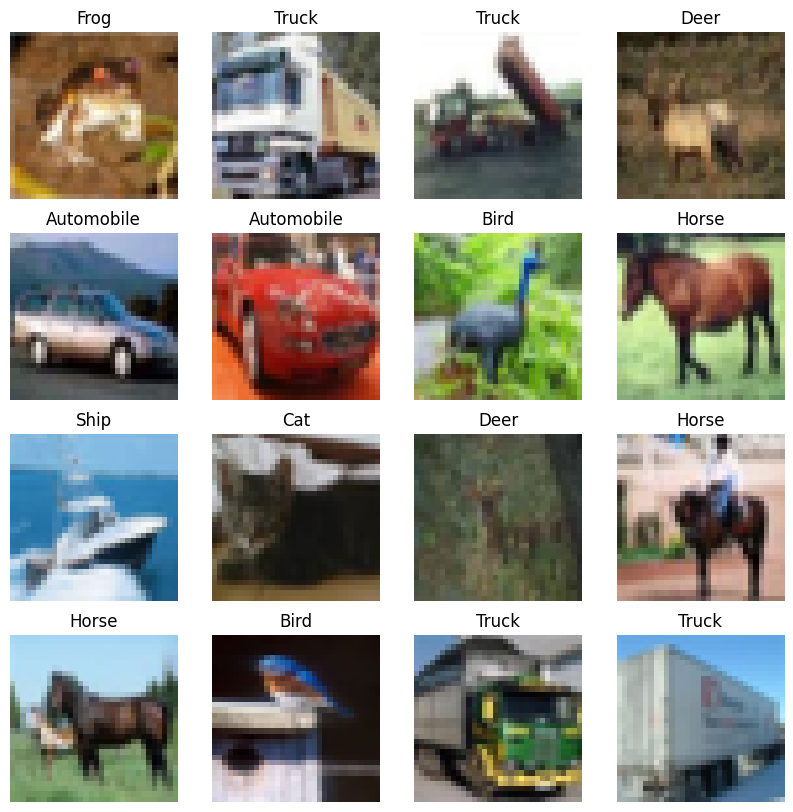

In [5]:
plt.figure(figsize=(10,10))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

In [6]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [7]:
y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

In [8]:
print(X_train.min(), X_train.max())
print(X_train.dtype)

0.0 1.0
float32


In [9]:
print(y_train_cat.shape)
print(y_test_cat.shape)

(50000, 10)
(10000, 10)


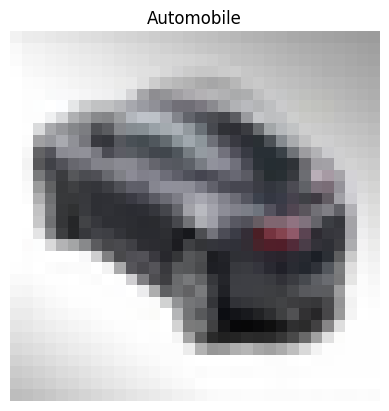

In [10]:
sample = np.random.randint(0,len(X_train))

plt.imshow(X_train[sample])
plt.title(class_names[np.argmax(y_train_cat[sample])])
plt.axis("off")
plt.show()

In [11]:
pd.Series(y_train.flatten()).value_counts()

,count
6,5000
9,5000
4,5000
1,5000
2,5000
7,5000
8,5000
3,5000
5,5000
0,5000


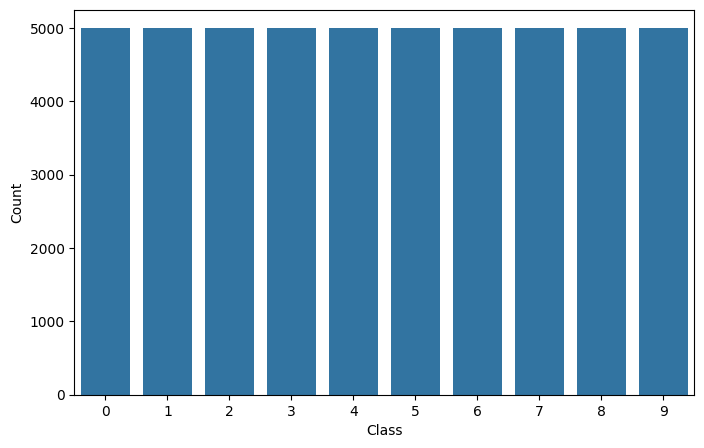

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(x=y_train.flatten())

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

In [13]:
print("Image Shape:", X_train[0].shape)

Image Shape: (32, 32, 3)


In [14]:
print(class_names)

['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']


In [15]:
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 50000
Testing Samples: 10000


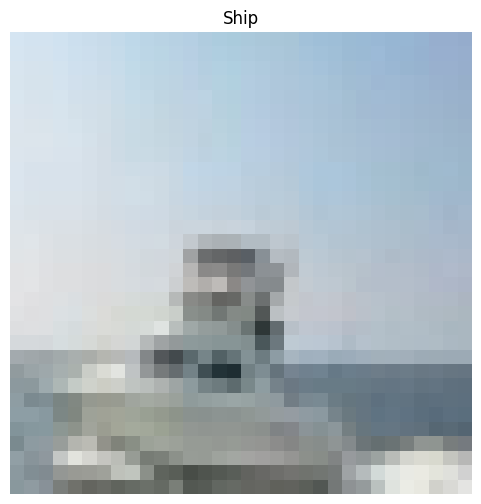

In [16]:
plt.figure(figsize=(6,6))

plt.imshow(X_train[100])

plt.title(class_names[np.argmax(y_train_cat[100])])

plt.axis("off")

plt.show()

In [17]:
print(np.unique(y_train))

[0 1 2 3 4 5 6 7 8 9]


In [18]:
train_df = pd.DataFrame({
    "Class": y_train.flatten()
})

train_df.head()

,Class
0,6
1,9
2,9
3,4
4,1


In [19]:
print(train_df["Class"].value_counts())

Class
6    5000
9    5000
4    5000
1    5000
2    5000
7    5000
8    5000
3    5000
5    5000
0    5000
Name: count, dtype: int64


In [20]:
print("Dataset Ready for ANN and CNN Training")

Dataset Ready for ANN and CNN Training


In [21]:
ann = Sequential([
    Flatten(input_shape=(32,32,3)),
    Dense(512,activation="relu"),
    Dense(256,activation="relu"),
    Dense(128,activation="relu"),
    Dense(10,activation="softmax")
])

ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
ann.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [23]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [24]:
history_ann = ann.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.3108 - loss: 1.9038 - val_accuracy: 0.3537 - val_loss: 1.7911
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.3896 - loss: 1.6965 - val_accuracy: 0.4056 - val_loss: 1.6683
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.4201 - loss: 1.6162 - val_accuracy: 0.4104 - val_loss: 1.6467
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.4415 - loss: 1.5637 - val_accuracy: 0.4368 - val_loss: 1.5820
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.4597 - loss: 1.5121 - val_accuracy: 0.4500 - val_loss: 1.5534
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.4682 - loss: 1.4837 - val_accuracy: 0.4179 - val_loss: 1.6642
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.4789 - loss: 1.4499 - val_accuracy: 0.4664 - val_loss: 1.5144
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.4887 - loss: 1.4221 - 

In [25]:
ann.evaluate(X_test,y_test_cat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4859 - loss: 1.4360


[1.4360034465789795, 0.48590001463890076]

In [26]:
ann_pred = ann.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [27]:
ann_pred_classes = np.argmax(ann_pred,axis=1)

In [28]:
true_classes = y_test.flatten()

In [29]:
print(classification_report(true_classes,ann_pred_classes,target_names=class_names))

              precision    recall  f1-score   support

    Airplane       0.60      0.51      0.55      1000
  Automobile       0.68      0.48      0.56      1000
        Bird       0.33      0.39      0.36      1000
         Cat       0.33      0.30      0.32      1000
        Deer       0.43      0.36      0.39      1000
         Dog       0.42      0.32      0.36      1000
        Frog       0.49      0.62      0.55      1000
       Horse       0.49      0.65      0.56      1000
        Ship       0.60      0.64      0.62      1000
       Truck       0.54      0.58      0.56      1000

    accuracy                           0.49     10000
   macro avg       0.49      0.49      0.48     10000
weighted avg       0.49      0.49      0.48     10000



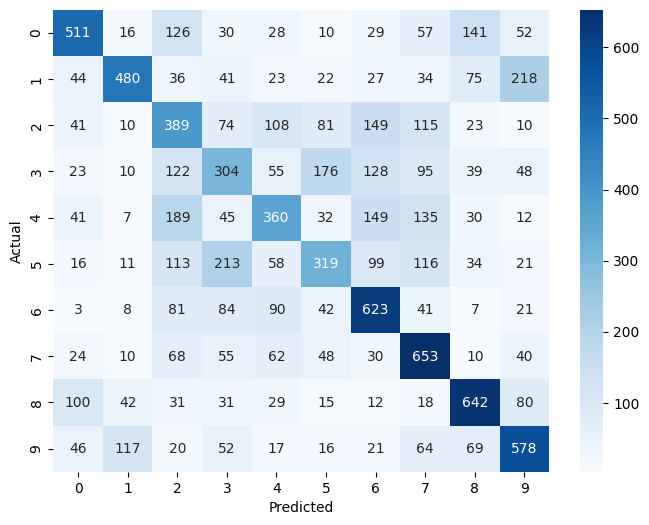

In [30]:
cm = confusion_matrix(true_classes,ann_pred_classes)

plt.figure(figsize=(8,6))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

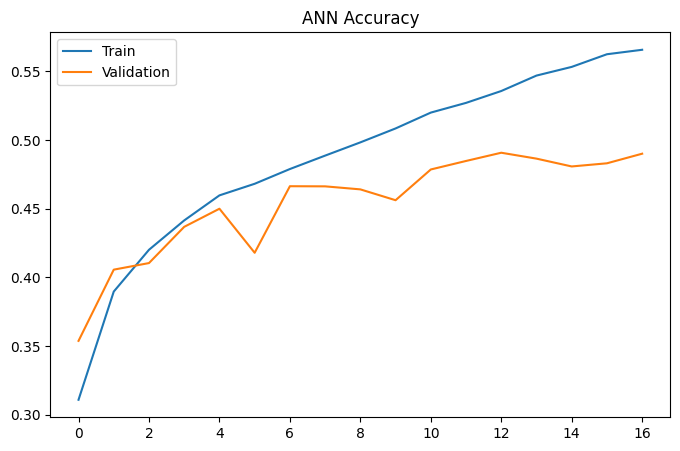

In [31]:
plt.figure(figsize=(8,5))

plt.plot(history_ann.history["accuracy"])

plt.plot(history_ann.history["val_accuracy"])

plt.legend(["Train","Validation"])

plt.title("ANN Accuracy")

plt.show()

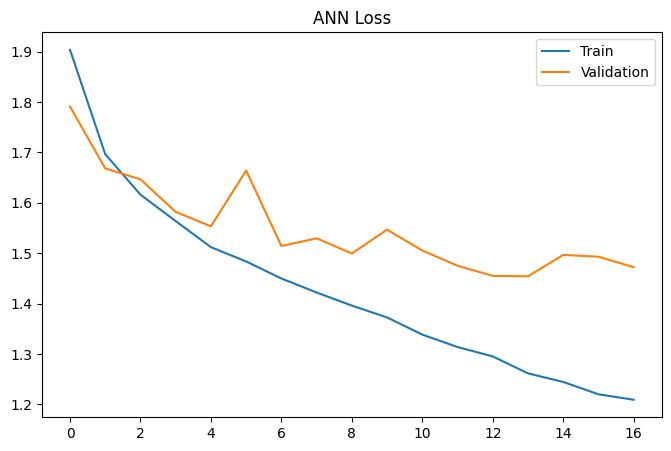

In [32]:
plt.figure(figsize=(8,5))

plt.plot(history_ann.history["loss"])

plt.plot(history_ann.history["val_loss"])

plt.legend(["Train","Validation"])

plt.title("ANN Loss")

plt.show()

In [33]:
ann_accuracy = ann.evaluate(X_test,y_test_cat,verbose=0)[1]

print(ann_accuracy)

0.48590001463890076


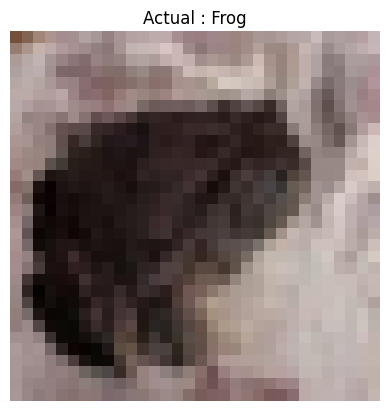

In [34]:
sample = np.random.randint(0,len(X_test))

plt.imshow(X_test[sample])

plt.title("Actual : "+class_names[true_classes[sample]])

plt.axis("off")

plt.show()

In [35]:
print("Predicted :",class_names[ann_pred_classes[sample]])

Predicted : Cat


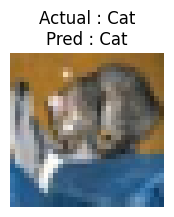

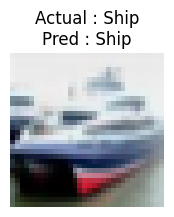

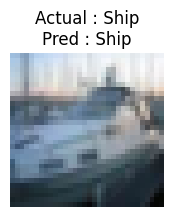

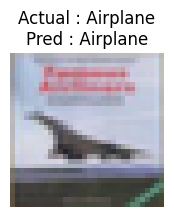

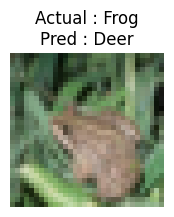

In [36]:
for i in range(5):

    plt.figure(figsize=(2,2))

    plt.imshow(X_test[i])

    plt.title("Actual : "+class_names[true_classes[i]]+"\nPred : "+class_names[ann_pred_classes[i]])

    plt.axis("off")

    plt.show()

In [37]:
ann.save("ANN_CIFAR10.keras")

In [38]:
from google.colab import files

files.download("ANN_CIFAR10.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
print("ANN Test Accuracy :",ann_accuracy)

ANN Test Accuracy : 0.48590001463890076


In [40]:
print("ANN Model Completed")

ANN Model Completed


In [41]:
cnn = Sequential([
    Conv2D(32,(3,3),padding="same",activation="relu",input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64,(3,3),padding="same",activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128,(3,3),padding="same",activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),

    Dense(256,activation="relu"),
    Dropout(0.5),

    Dense(10,activation="softmax")
])

cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [42]:
cnn.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [43]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

In [44]:
checkpoint = ModelCheckpoint(
    "Best_CNN.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [45]:
history_cnn = cnn.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop,checkpoint]
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 127ms/step - accuracy: 0.3673 - loss: 1.7596 - val_accuracy: 0.4755 - val_loss: 1.5589
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 132ms/step - accuracy: 0.4799 - loss: 1.4374 - val_accuracy: 0.5807 - val_loss: 1.1552
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 130ms/step - accuracy: 0.5475 - loss: 1.2678 - val_accuracy: 0.4930 - val_loss: 1.5935
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 129ms/step - accuracy: 0.5893 - loss: 1.1594 - val_accuracy: 0.6669 - val_loss: 0.9539
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 130ms/step - accuracy: 0.6217 - loss: 1.0793 - val_accuracy: 0.6550 - val_loss: 0.9739
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 125ms/step - accuracy: 0.6436 - loss: 1.0141 - val_accuracy: 0.6831 - val_loss: 0.8947
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 126ms/step - accuracy: 0.6678 - loss: 0.9547 - val_accuracy: 0.6282 - val_loss: 1.1036
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 129ms/step - accuracy: 0.6801 - loss: 0

In [46]:
cnn.evaluate(X_test,y_test_cat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7562 - loss: 0.7021


[0.7020621299743652, 0.7562000155448914]

In [47]:
cnn_pred = cnn.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


In [48]:
cnn_pred_classes = np.argmax(cnn_pred,axis=1)

In [49]:
print(classification_report(
    true_classes,
    cnn_pred_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

    Airplane       0.74      0.84      0.79      1000
  Automobile       0.87      0.88      0.87      1000
        Bird       0.64      0.66      0.65      1000
         Cat       0.54      0.61      0.57      1000
        Deer       0.74      0.68      0.71      1000
         Dog       0.66      0.63      0.64      1000
        Frog       0.82      0.83      0.83      1000
       Horse       0.83      0.79      0.81      1000
        Ship       0.87      0.85      0.86      1000
       Truck       0.89      0.79      0.84      1000

    accuracy                           0.76     10000
   macro avg       0.76      0.76      0.76     10000
weighted avg       0.76      0.76      0.76     10000



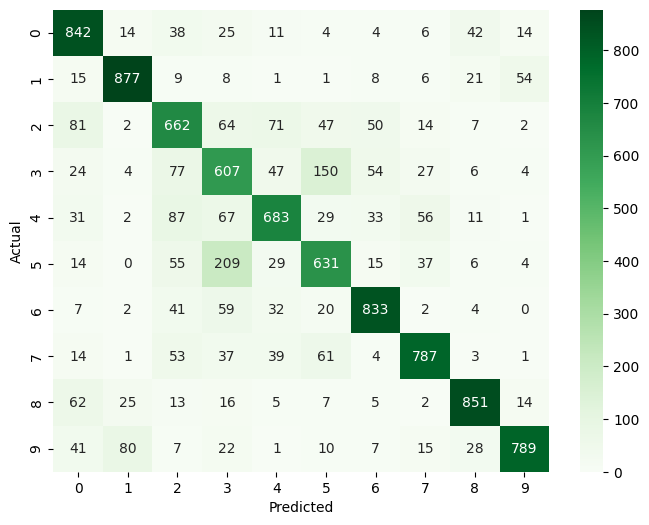

In [50]:
cm = confusion_matrix(
    true_classes,
    cnn_pred_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

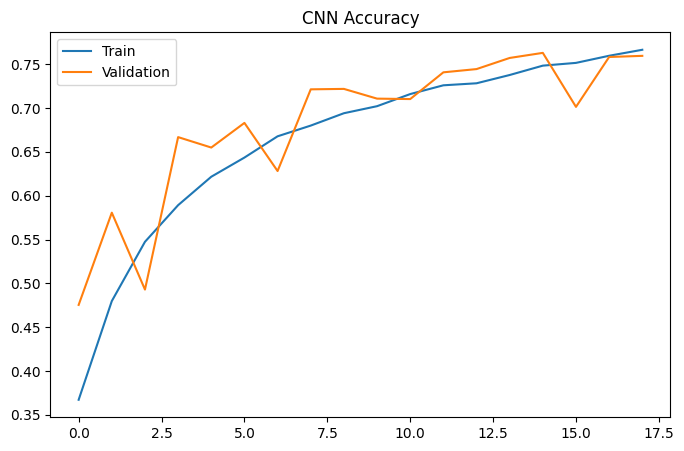

In [51]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history["accuracy"])

plt.plot(history_cnn.history["val_accuracy"])

plt.legend(["Train","Validation"])

plt.title("CNN Accuracy")

plt.show()

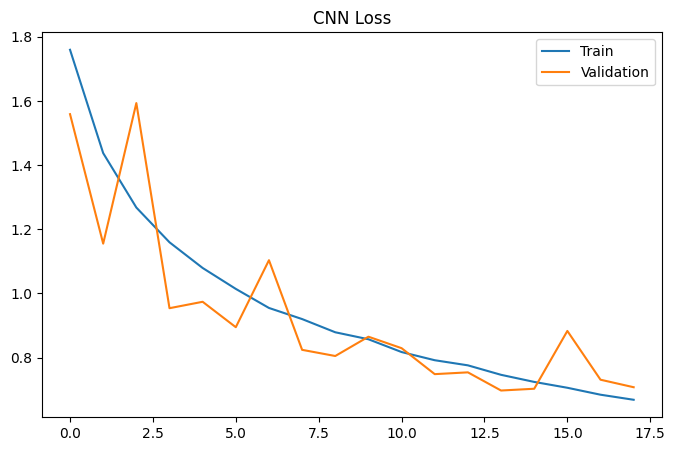

In [52]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history["loss"])

plt.plot(history_cnn.history["val_loss"])

plt.legend(["Train","Validation"])

plt.title("CNN Loss")

plt.show()

In [53]:
cnn_accuracy = cnn.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)[1]

print(cnn_accuracy)

0.7562000155448914


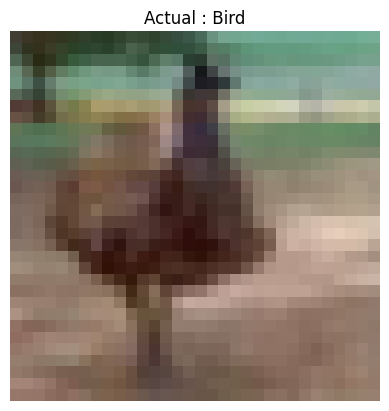

In [54]:
sample = np.random.randint(
    0,
    len(X_test)
)

plt.imshow(X_test[sample])

plt.title(
    "Actual : "+
    class_names[true_classes[sample]]
)

plt.axis("off")

plt.show()

In [55]:
print(
    "Predicted :",
    class_names[
        cnn_pred_classes[sample]
    ]
)

Predicted : Bird


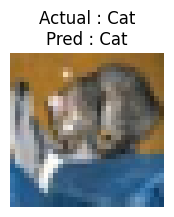

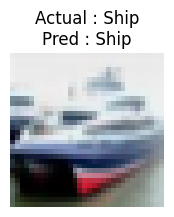

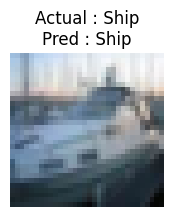

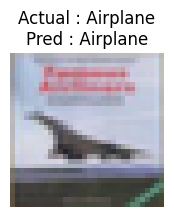

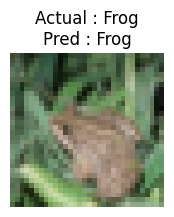

In [56]:
for i in range(5):

    plt.figure(figsize=(2,2))

    plt.imshow(X_test[i])

    plt.title(
        "Actual : "
        + class_names[true_classes[i]]
        + "\nPred : "
        + class_names[cnn_pred_classes[i]]
    )

    plt.axis("off")

    plt.show()

In [57]:
comparison = pd.DataFrame({

    "Model":[
        "ANN",
        "CNN"
    ],

    "Accuracy":[
        ann_accuracy,
        cnn_accuracy
    ]

})

comparison

,Model,Accuracy
0,ANN,0.4859
1,CNN,0.7562


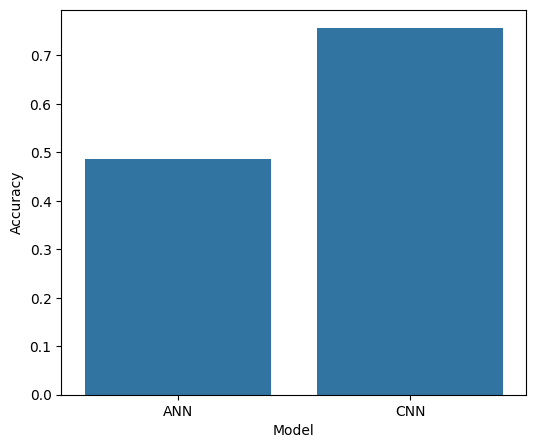

In [58]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.show()

In [59]:
cnn.save(
    "CNN_CIFAR10.keras"
)

In [60]:
print("CNN Completed Successfully")

CNN Completed Successfully


In [61]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.2
)

datagen.fit(X_train)

In [63]:
cnn_aug = Sequential([
    Conv2D(32,(3,3),padding="same",activation="relu",input_shape=(32,32,3)),
    BatchNormalization(),
    Conv2D(32,(3,3),activation="relu"),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64,(3,3),padding="same",activation="relu"),
    BatchNormalization(),
    Conv2D(64,(3,3),activation="relu"),
    MaxPooling2D((2,2)),
    Dropout(0.30),

    Conv2D(128,(3,3),padding="same",activation="relu"),
    BatchNormalization(),
    Conv2D(128,(3,3),activation="relu"),
    MaxPooling2D((2,2)),
    Dropout(0.35),

    Flatten(),

    Dense(512,activation="relu"),
    Dropout(0.5),

    Dense(10,activation="softmax")
])

cnn_aug.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 555,690 (2.12 MB)

 Trainable params: 555,242 (2.12 MB)

 Non-trainable params: 448 (1.75 KB)

In [64]:
cnn_aug.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [65]:
early_stop_aug = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [66]:
checkpoint_aug = ModelCheckpoint(
    "Best_Augmented_CNN.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [67]:
history_aug = cnn_aug.fit(
    datagen.flow(X_train,y_train_cat,batch_size=64),
    validation_data=(X_test,y_test_cat),
    epochs=20,
    callbacks=[early_stop_aug,checkpoint_aug]
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 209s 263ms/step - accuracy: 0.3599 - loss: 1.7632 - val_accuracy: 0.4769 - val_loss: 1.4278
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 204s 261ms/step - accuracy: 0.4879 - loss: 1.4268 - val_accuracy: 0.5431 - val_loss: 1.2569
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 206s 263ms/step - accuracy: 0.5459 - loss: 1.2805 - val_accuracy: 0.5479 - val_loss: 1.3378
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 208s 266ms/step - accuracy: 0.5845 - loss: 1.1796 - val_accuracy: 0.6562 - val_loss: 0.9519
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 212s 272ms/step - accuracy: 0.6166 - loss: 1.0974 - val_accuracy: 0.6769 - val_loss: 0.9278
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 215s 275ms/step - accuracy: 0.6383 - loss: 1.0396 - val_accuracy: 0.7036 - val_loss: 0.8452
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 228s 292ms/step - accuracy: 0.6563 - loss: 0.9951 - val_accuracy: 0.6309 - val_loss: 1.0648
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 234s 300ms/step - accuracy: 0.6708 -

In [68]:
cnn_aug.evaluate(X_test,y_test_cat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.7888 - loss: 0.6217


[0.6217000484466553, 0.7888000011444092]

In [69]:
aug_pred = cnn_aug.predict(X_test)

aug_pred_classes = np.argmax(aug_pred,axis=1)

aug_accuracy = cnn_aug.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)[1]

print(aug_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step
0.7888000011444092


In [70]:
print(classification_report(
    true_classes,
    aug_pred_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

    Airplane       0.82      0.79      0.80      1000
  Automobile       0.89      0.93      0.91      1000
        Bird       0.78      0.68      0.72      1000
         Cat       0.70      0.57      0.63      1000
        Deer       0.80      0.72      0.76      1000
         Dog       0.80      0.61      0.69      1000
        Frog       0.62      0.95      0.75      1000
       Horse       0.89      0.80      0.84      1000
        Ship       0.83      0.92      0.87      1000
       Truck       0.83      0.92      0.87      1000

    accuracy                           0.79     10000
   macro avg       0.80      0.79      0.79     10000
weighted avg       0.80      0.79      0.79     10000



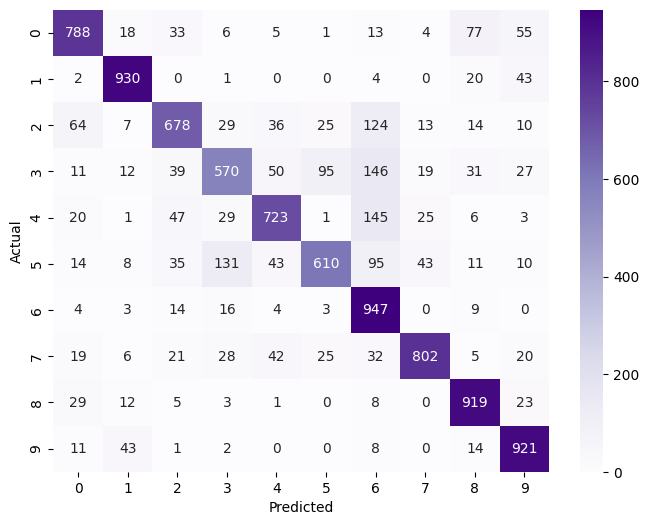

In [71]:
cm = confusion_matrix(
    true_classes,
    aug_pred_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

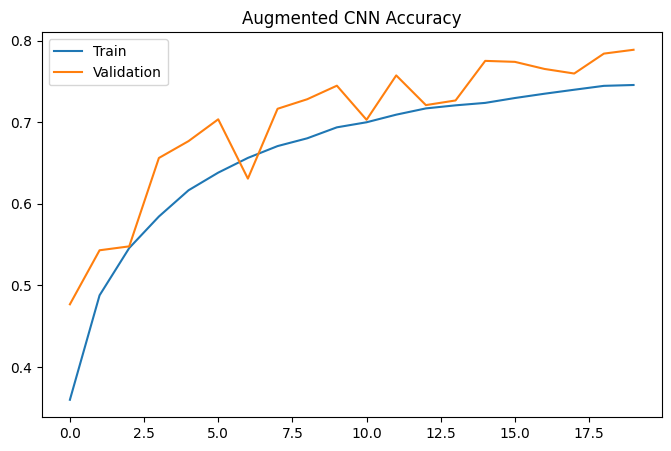

In [72]:
plt.figure(figsize=(8,5))

plt.plot(history_aug.history["accuracy"])

plt.plot(history_aug.history["val_accuracy"])

plt.legend(["Train","Validation"])

plt.title("Augmented CNN Accuracy")

plt.show()

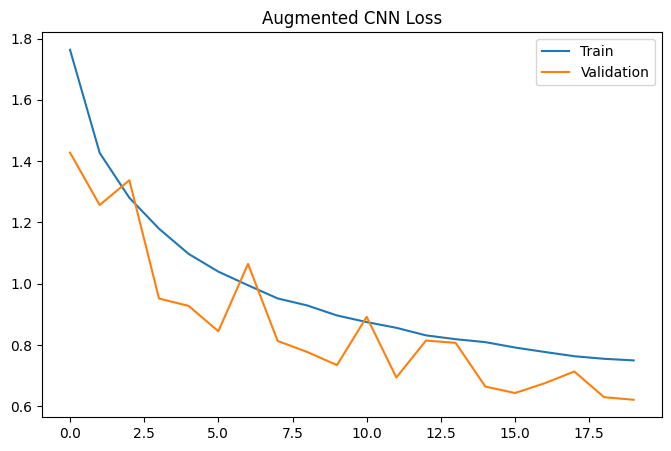

In [73]:
plt.figure(figsize=(8,5))

plt.plot(history_aug.history["loss"])

plt.plot(history_aug.history["val_loss"])

plt.legend(["Train","Validation"])

plt.title("Augmented CNN Loss")

plt.show()

In [74]:
comparison = pd.DataFrame({

    "Model":[
        "ANN",
        "CNN",
        "CNN + Augmentation"
    ],

    "Accuracy":[
        ann_accuracy,
        cnn_accuracy,
        aug_accuracy
    ]

})

comparison

,Model,Accuracy
0,ANN,0.4859
1,CNN,0.7562
2,CNN + Augmentation,0.7888


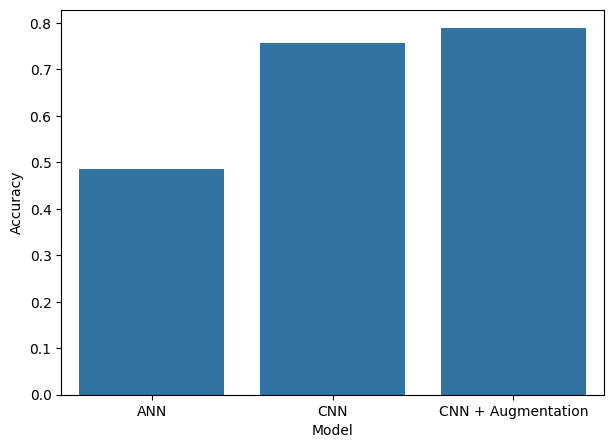

In [75]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.show()

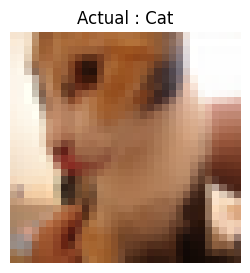

In [76]:
sample = np.random.randint(0,len(X_test))

plt.figure(figsize=(3,3))

plt.imshow(X_test[sample])

plt.title(
    "Actual : "+class_names[true_classes[sample]]
)

plt.axis("off")

plt.show()

In [77]:
print(
    "Predicted :",
    class_names[
        aug_pred_classes[sample]
    ]
)

Predicted : Cat


In [78]:
cnn_aug.save("Final_CIFAR10_Model.keras")

In [79]:
from google.colab import files

files.download("Final_CIFAR10_Model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [80]:
comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
2,CNN + Augmentation,0.7888
1,CNN,0.7562
0,ANN,0.4859


In [81]:
print("Project Completed Successfully")

Project Completed Successfully
